# Clustering Analysis: Global Cybersecurity Threats (2015–2024)

This notebook performs **K-Means** and **DBSCAN** clustering on numeric features from the cleaned cybersecurity dataset. Steps include preprocessing, scaling, elbow-method selection of **K**, clustering, **PCA** projection to 2D, and scatter-plot visualization.

In [1]:
# Standard library
from pathlib import Path

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, DBSCAN
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Plot style (matplotlib only)
plt.style.use("ggplot")
np.random.seed(42)

## Step 1 — Load dataset

Load the CSV from the same directory as this notebook (adjust `DATA_PATH` if your file lives elsewhere).

In [2]:
# Path to dataset (same folder as this notebook by default)
DATA_PATH = Path("Global_Cybersecurity_Threats_2015-2024_cleaned.csv")

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


## Steps 2–4 — Numeric features, missing values, scaling

- **Step 2:** Keep only numeric columns suitable for distance-based clustering.
- **Step 3:** Impute missing values with the **median** (robust to outliers); rows that are all-NaN after selection are dropped if needed.
- **Step 4:** Apply **StandardScaler** (zero mean, unit variance) so K-Means and DBSCAN are not dominated by large-magnitude features.

In [3]:
# Step 2: numeric features only
X = df.select_dtypes(include=[np.number]).copy()
feature_names = X.columns.tolist()
print("Numeric columns used:", feature_names)

# Step 3: missing values
missing_before = X.isna().sum().sum()
print(f"Total missing values before imputation: {missing_before}")
if missing_before > 0:
    imputer = SimpleImputer(strategy="median")
    X_imputed = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index,
    )
else:
    imputer = None
    X_imputed = X.copy()

# Drop any row that is still invalid (e.g., all NaN originally — rare)
X_imputed = X_imputed.dropna()
print(f"Samples after cleaning: {len(X_imputed)}")

# Step 4: scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = np.asarray(X_scaled, dtype=np.float64)
print("Scaled matrix shape:", X_scaled.shape)

Numeric columns used: ['Year', 'Financial Loss (in Million $)', 'Number of Affected Users', 'Incident Resolution Time (in Hours)']
Total missing values before imputation: 0
Samples after cleaning: 3000
Scaled matrix shape: (3000, 4)


## Step 5 — Elbow method for optimal K (K-Means)

We compute **inertia** (within-cluster sum of squares) for a range of **K** values and plot the **elbow curve**. The "elbow" is where the rate of decrease slows; we also print inertia values to support your choice of **K**.

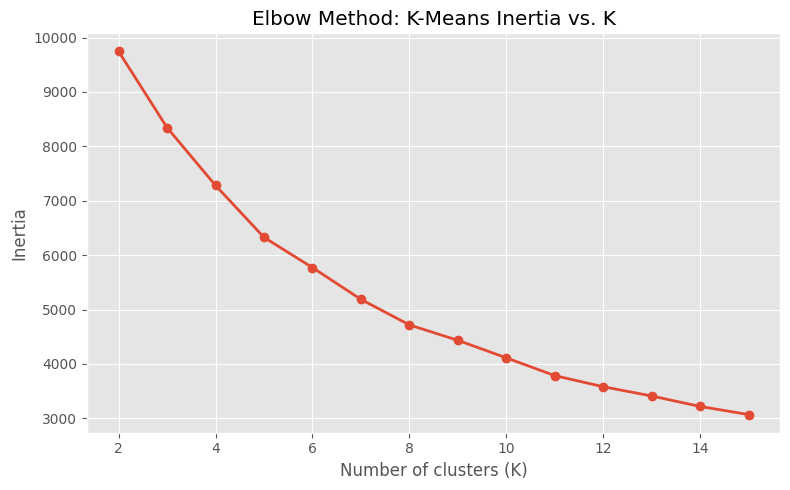

,K,Inertia,Delta_inertia
0,2,9743.352501,NaN
1,3,8343.145296,-1400.207205
2,4,7280.789995,-1062.355302
3,5,6326.111694,-954.678301
4,6,5770.967390,-555.144304
5,7,5186.626008,-584.341383
6,8,4717.294775,-469.331233
7,9,4433.817751,-283.477025
8,10,4111.634257,-322.183494
9,11,3784.901046,-326.733211


In [4]:
K_range = range(2, 16)
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, marker="o", linewidth=2)
ax.set_xlabel("Number of clusters (K)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method: K-Means Inertia vs. K")
plt.tight_layout()
plt.savefig("figures/week12_elbow_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Tabular view to spot the elbow
elbow_df = pd.DataFrame({"K": list(K_range), "Inertia": inertias})
elbow_df["Delta_inertia"] = elbow_df["Inertia"].diff()
display(elbow_df)


## Step 6 — Apply K-Means clustering

The model is fit on **scaled** data; labels are stored in `labels_kmeans`.

**Why K = 4:** The elbow plot and `Delta_inertia` table in Step 5 show a large reduction in inertia moving from K = 3 to K = 4, and smaller *marginal* drops afterward (the curve begins to flatten). **K = 4** is therefore a reasonable elbow choice—enough clusters to reflect structure without choosing an unnecessarily large K.


### K-Means: choice of K = 4

- The elbow curve shows a noticeable bend around **K = 4**.
- After **K = 4**, inertia still decreases, but the **improvement slows**.
- **K = 4** was selected as a **balanced and interpretable** clustering choice.


In [5]:
# K = 4 aligns with the elbow in Step 5 (see markdown above)
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init="auto")
labels_kmeans = kmeans.fit_predict(X_scaled)

print(f"K-Means with K={OPTIMAL_K}")
print("Cluster sizes:", pd.Series(labels_kmeans).value_counts().sort_index().to_dict())


K-Means with K=4
Cluster sizes: {0: 722, 1: 750, 2: 740, 3: 788}


## Step 7 — DBSCAN clustering

**DBSCAN** uses `eps` (neighborhood radius in scaled space) and `min_samples` (minimum points to form a dense region).

### Tuning three candidates

Below we test exactly three `(eps, min_samples)` pairs and print, for each: number of clusters (excluding noise), number of noise points, and cluster label counts.

### Why we keep the chosen `eps` and `min_samples`

On this scaled data, **larger `eps` with the tested `min_samples` values** tends to merge almost all points into **one** cluster (little separation). The **tighter** setting **`eps = 0.5`, `min_samples = 5`** is the only candidate here that recovers **multiple density regions** and explicitly marks outliers as noise—better aligned with density-based clustering for the write-up. Adjust if you prefer fewer small clusters or less noise.


In [6]:
# DBSCAN: compare three parameter combinations (scaled feature space)
DBSCAN_TUNING = [
    (0.5, 5),
    (1.0, 5),
    (1.5, 10),
]

for eps, ms in DBSCAN_TUNING:
    dbs = DBSCAN(eps=eps, min_samples=ms)
    labels = dbs.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"\n=== eps={eps}, min_samples={ms} ===")
    print(f"Number of clusters (excluding noise): {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print(f"Cluster label counts: {counts}")



=== eps=0.5, min_samples=5 ===
Number of clusters (excluding noise): 10
Number of noise points: 146
Cluster label counts: {-1: 146, 0: 2813, 1: 8, 2: 2, 3: 6, 4: 4, 5: 5, 6: 4, 7: 6, 8: 3, 9: 3}

=== eps=1.0, min_samples=5 ===
Number of clusters (excluding noise): 1
Number of noise points: 0
Cluster label counts: {0: 3000}

=== eps=1.5, min_samples=10 ===
Number of clusters (excluding noise): 1
Number of noise points: 0
Cluster label counts: {0: 3000}


### Final DBSCAN parameters

- Several **DBSCAN** parameter combinations were tested.
- **Larger epsilon** values merged the dataset into **one** cluster.
- **More restrictive** settings labeled **too many** observations as noise.
- **`eps = 0.5`** and **`min_samples = 5`** were retained because it was the **only** configuration that produced **multiple density-based regions** with a **manageable** amount of noise.


In [7]:
# Final DBSCAN fit (used for PCA plot below)
EPS_DBSCAN = 0.5
MIN_SAMPLES_DBSCAN = 5

dbscan = DBSCAN(eps=EPS_DBSCAN, min_samples=MIN_SAMPLES_DBSCAN)
labels_dbscan = dbscan.fit_predict(X_scaled)

print(f"\n--- Final DBSCAN (used for PCA plot): eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN} ---")
print("Cluster label counts:", pd.Series(labels_dbscan).value_counts().sort_index().to_dict())



--- Final DBSCAN (used for PCA plot): eps=0.5, min_samples=5 ---
Cluster label counts: {-1: 146, 0: 2813, 1: 8, 2: 2, 3: 6, 4: 4, 5: 5, 6: 4, 7: 6, 8: 3, 9: 3}


### DBSCAN follow-up tuning (two additional comparisons)

Below we run the same diagnostics for **`eps = 0.45`, `min_samples = 10`** and **`eps = 0.40`, `min_samples = 10`** on the scaled data, without changing the fitted model used for the PCA plot (still **`eps = 0.5`, `min_samples = 5`** above).


In [8]:
# Additional DBSCAN comparisons (does not change EPS_DBSCAN / MIN_SAMPLES_DBSCAN used below)
DBSCAN_FOLLOWUP = [
    (0.45, 10),
    (0.40, 10),
]

for eps, ms in DBSCAN_FOLLOWUP:
    dbs = DBSCAN(eps=eps, min_samples=ms)
    labels = dbs.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int(np.sum(labels == -1))
    counts = pd.Series(labels).value_counts().sort_index().to_dict()
    print(f"\n=== Follow-up: eps={eps}, min_samples={ms} ===")
    print(f"Number of clusters (excluding noise): {n_clusters}")
    print(f"Number of noise points: {n_noise}")
    print(f"Cluster label counts: {counts}")



=== Follow-up: eps=0.45, min_samples=10 ===
Number of clusters (excluding noise): 22
Number of noise points: 2708
Cluster label counts: {-1: 2708, 0: 10, 1: 11, 2: 27, 3: 12, 4: 19, 5: 12, 6: 18, 7: 10, 8: 14, 9: 23, 10: 19, 11: 16, 12: 10, 13: 10, 14: 10, 15: 12, 16: 10, 17: 10, 18: 9, 19: 10, 20: 10, 21: 10}

=== Follow-up: eps=0.4, min_samples=10 ===
Number of clusters (excluding noise): 2
Number of noise points: 2975
Cluster label counts: {-1: 2975, 0: 15, 1: 10}


**Comparison with `eps = 0.5`, `min_samples = 5` (current PCA choice):** Neither follow-up setting yields *cleaner* density-based structure for this dataset. With **`min_samples = 10`** and slightly smaller **`eps`**, DBSCAN labels **far more points as noise** (and at `eps = 0.45` it splits into **many** small clusters). At **`eps = 0.40`**, almost all points become noise with only **two** tiny core clusters—less interpretable than the current choice, which keeps a **single large dense region** plus moderate noise and smaller satellite clusters. For your write-up, **`0.5 / 5`** remains the more balanced baseline unless you deliberately prioritize high noise rate or many micro-clusters.


## Steps 8–9 — PCA to 2D and scatter plots

**PCA** projects scaled data onto two principal components for visualization. Scatter plots show **K-Means** and **DBSCAN** partitions in this 2D space (noise points for DBSCAN are shown distinctly).

### Final Clustering Interpretation

The clustering analysis reveals that the dataset contains both broad structural groupings and localized density variations. K-Means identifies four major segments based on overall feature similarity, providing a clear and interpretable high-level partition of the data.

DBSCAN, in contrast, highlights the density-based structure of the dataset. It identifies one dominant dense region, several smaller clusters, and 146 noise points. These noise points may represent unusual or extreme cybersecurity events, such as incidents with exceptionally high financial losses or unusually long resolution times.

Together, these methods provide complementary insights. K-Means is effective for identifying general patterns and segmenting the dataset into meaningful groups, while DBSCAN is valuable for detecting anomalies and uncovering hidden density structures. This combination offers a more complete understanding of the underlying behavior of cybersecurity incidents.

Explained variance ratio: PC1=0.255, PC2=0.251
Total variance explained (2D): 0.506


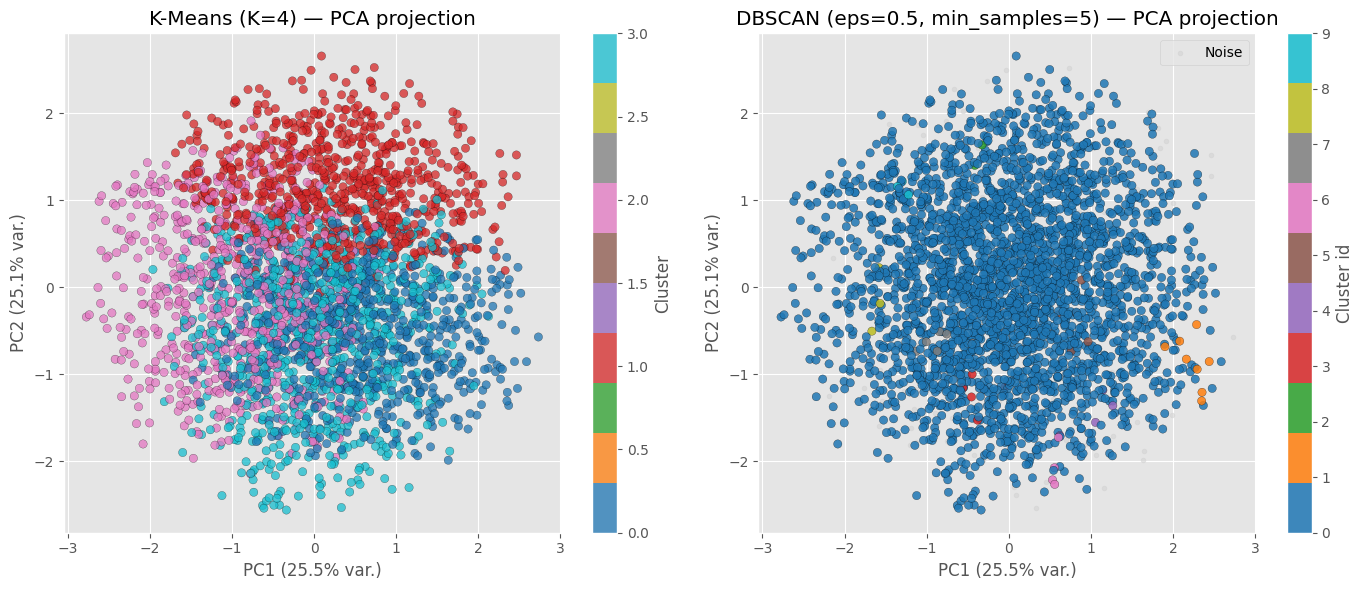

In [9]:
# Step 8: PCA (2 components)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f"Explained variance ratio: PC1={explained[0]:.3f}, PC2={explained[1]:.3f}")
print(f"Total variance explained (2D): {explained.sum():.3f}")

# Step 9: visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# K-Means
scatter_km = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_kmeans,
    cmap="tab10",
    alpha=0.75,
    edgecolors="k",
    linewidths=0.2,
)
axes[0].set_title(f"K-Means (K={OPTIMAL_K}) — PCA projection")
axes[0].set_xlabel(f"PC1 ({explained[0]*100:.1f}% var.)")
axes[0].set_ylabel(f"PC2 ({explained[1]*100:.1f}% var.)")
plt.colorbar(scatter_km, ax=axes[0], label="Cluster")

# DBSCAN: show noise separately
is_noise = labels_dbscan == -1
axes[1].scatter(
    X_pca[is_noise, 0],
    X_pca[is_noise, 1],
    c="lightgray",
    s=12,
    label="Noise",
    alpha=0.6,
)
mask_core = ~is_noise
scatter_db = axes[1].scatter(
    X_pca[mask_core, 0],
    X_pca[mask_core, 1],
    c=labels_dbscan[mask_core],
    cmap="tab10",
    alpha=0.85,
    edgecolors="k",
    linewidths=0.2,
)
axes[1].set_title(
    f"DBSCAN (eps={EPS_DBSCAN}, min_samples={MIN_SAMPLES_DBSCAN}) — PCA projection"
)
axes[1].set_xlabel(f"PC1 ({explained[0]*100:.1f}% var.)")
axes[1].set_ylabel(f"PC2 ({explained[1]*100:.1f}% var.)")
axes[1].legend(loc="best")
plt.colorbar(scatter_db, ax=axes[1], label="Cluster id")

plt.tight_layout()
plt.savefig("figures/week12_kmeans_dbscan_pca.png", dpi=300, bbox_inches="tight")
plt.show()


### Reading the PCA cluster plots

- **K-Means** produced the most **interpretable** result, identifying **four broad groups**.
- **DBSCAN** was more sensitive to density and mostly detected **one dominant dense region**, **several small clusters**, and a set of **noise** points.
- Together, this suggests the data contains **broader global structure** (partition-style groups) rather than **strong density-separated** groupings throughout.


In [10]:
# Week 12 summary: methods and results
summary_df = pd.DataFrame(
    [
        {
            "Method": "K-Means",
            "Final Parameters": "K=4",
            "Key Result": "Produced four broad, interpretable clusters",
        },
        {
            "Method": "DBSCAN",
            "Final Parameters": "eps=0.5, min_samples=5",
            "Key Result": "Produced one dominant cluster, several small clusters, and 146 noise points",
        },
    ]
)
display(summary_df)


,Method,Final Parameters,Key Result
0,K-Means,K=4,"Produced four broad, interpretable clusters"
1,DBSCAN,"eps=0.5, min_samples=5","Produced one dominant cluster, several small c..."
